# Intro: Exploración mínima del Parquet del S&P 500

Objetivo: tener una **vista rápida y didáctica** del dataset para saber qué contiene, cómo está organizado y si es usable.

No es un análisis profundo; es una **introducción** para empezar los demás ejercicios con confianza.

Aquí solo comprobaremos estructura, tipos, rangos y una validación visual básica (sin calcular retornos ni hacer backtests).


## 0) Imports y configuración

Usamos pocas librerías: `pandas` para datos, `numpy` para utilidades numéricas y `matplotlib` para una gráfica rápida.

También dejamos una opción para cargar todo o una muestra, por si el fichero es grande y queremos una primera revisión ligera.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

PARQUET_NAME = "sp500_history.parquet"
LOAD_ALL = True          # Si es False, se usa una muestra aleatoria
SAMPLE_FRAC = 0.2        # Proporcion de la muestra cuando LOAD_ALL = False
RANDOM_SEED = 42


## 1) Resolver ruta y cargar datos

Localizamos el Parquet buscando desde el directorio actual hacia arriba, para evitar problemas de rutas.

Cargamos solo columnas esenciales (fecha, símbolo, precio y pertenencia al S&P 500), convertimos la fecha a `datetime` y, si hace falta, tomamos una muestra aleatoria.


In [2]:
# Resolver ruta del Parquet de forma robusta
def find_parquet(start_dir: Path, filename: str) -> Path:
    # Busca el archivo subiendo niveles desde el directorio actual
    for p in [start_dir, *start_dir.parents]:
        candidate = p / filename
        if candidate.exists():
            return candidate
    return None

cwd = Path.cwd()
parquet_path = find_parquet(cwd, PARQUET_NAME)

if parquet_path is None:
    raise FileNotFoundError(
        f"No se encuentra el archivo: {PARQUET_NAME}. \nAsegurate de estar dentro de la carpeta del proyecto o sube el parquet."
    )

print(f"Archivo: {parquet_path}")


Archivo: c:\Users\diego\MIAX\08-backtesting\sp500_history.parquet


In [3]:
# INspecciono  columnas del parquet
df = pd.read_parquet(parquet_path)
print("Columnas del DataFrame:")
print(df.columns.tolist())

Columnas del DataFrame:
['date', 'symbol', 'assetid', 'security_name', 'sector', 'industry', 'subsector', 'in_sp500', 'open', 'high', 'low', 'close', 'volume', 'unadjusted_close']


In [4]:
# Cargar columnas basicas para la intro
usecols = ["date", "symbol", "close", "in_sp500"]

df = pd.read_parquet(parquet_path, columns=usecols)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

if not LOAD_ALL:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)

print("Shape:", df.shape)
appl_df = df[df['symbol']=='NVDA']


Shape: (7250110, 4)


## 2) Vista rápida del dataset

Aquí hacemos una inspección inmediata:
- Confirmamos columnas disponibles.
- Revisamos tipos de datos.
- Miramos el tamaño y el uso de memoria.

Esto ayuda a detectar errores de formato antes de cualquier cálculo.

In [5]:
# Tipos de datos, shape y uso de memoria
print("─── Tipos de datos ───")
print(df.dtypes)
print(f"\nShape:           {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Uso de memoria:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Valores nulos:\n{df.isnull().sum()}")

─── Tipos de datos ───
date        datetime64[ns]
symbol              object
close              float32
in_sp500             int32
dtype: object

Shape:           7,250,110 filas × 4 columnas
Uso de memoria:  512.0 MB
Valores nulos:
date        0
symbol      0
close       0
in_sp500    0
dtype: int64


## 3) Comprobaciones rápidas

Calculamos un resumen muy simple para validar el dataset:
- Rango de fechas y número de símbolos.
- Duplicados por `date` + `symbol`.
- Distribución de `in_sp500` para ver cuántas observaciones están dentro del índice.

Si algo raro aparece aquí, es mejor corregirlo antes de seguir.

In [8]:
# Rango de fechas y número de símbolos
print(f"Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Símbolos únicos:    {df['symbol'].nunique()}")

# Duplicados por date + symbol
dupes = df.duplicated(subset=["date", "symbol"]).sum()
print(f"Duplicados (date+symbol): {dupes}")

# Distribución de in_sp500
print("\nDistribución in_sp500:")
print(df["in_sp500"].value_counts().rename({0: "Fuera del índice", 1: "En el índice"}))

Rango de fechas:    1990-01-02 → 2026-01-30
Símbolos únicos:    1289
Duplicados (date+symbol): 0

Distribución in_sp500:
in_sp500
En el índice        4555024
Fuera del índice    2695086
Name: count, dtype: int64


## 4) Ejemplo simple de series

Graficamos unas pocas acciones para comprobar que las series son coherentes en el tiempo.

No buscamos conclusiones: solo verificar continuidad y que el `close` luce razonable.

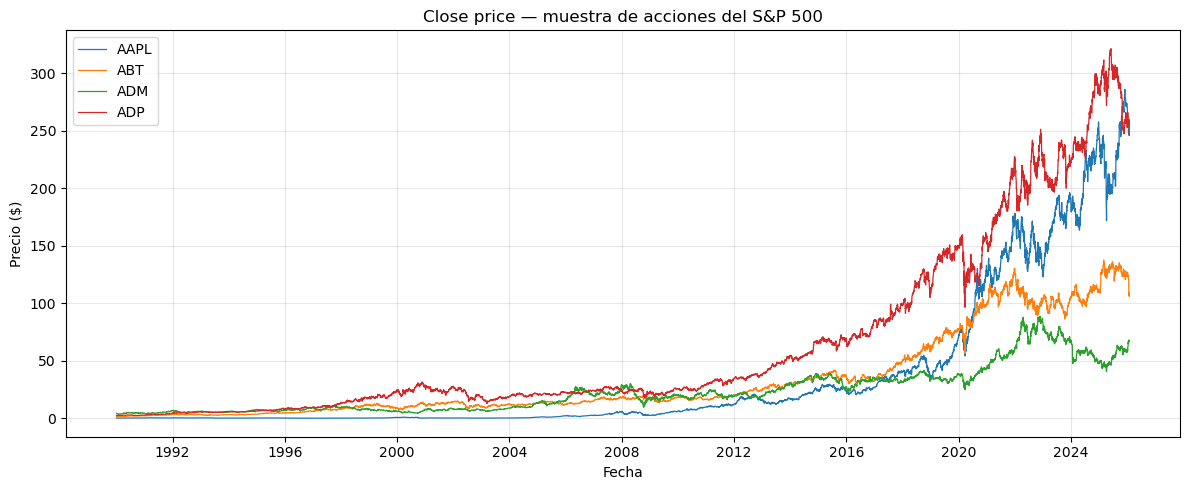

In [9]:
# Elegir 4 acciones con in_sp500=1 y más historia
symbols = (
    df[df["in_sp500"] == 1]
    .groupby("symbol")["date"].count()
    .nlargest(4)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))
for sym in symbols:
    sub = df[df["symbol"] == sym].sort_values("date")
    ax.plot(sub["date"], sub["close"], label=sym, linewidth=0.9)

ax.set_title("Close price — muestra de acciones del S&P 500")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Estrategia Breakout Volume

In [10]:
"""
run_breakout_strategy.py
========================
Script principal: carga el parquet del S&P 500, aplica la estrategia
de breakout con confirmación de volumen, y calcula métricas de
rentabilidad.

Lógica de operación:
    COMPRA  → close rompe donchian_upper con volumen y tendencia ✓
    VENTA   → close rompe donchian_lower (ruptura bajista)
    NEUTRO  → entre señales, no hay posición abierta

Métricas calculadas:
    - Retorno forward a N días desde cada señal (parametrizable)
    - Rentabilidad acumulada de la estrategia (long-only)
    - Estadísticos descriptivos por señal

Uso:
    python run_breakout_strategy.py

    O importar y llamar a main() con parámetros personalizados.
"""

# ═══════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════

from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ═══════════════════════════════════════════════════════════════
# 1) PARÁMETROS
# ═══════════════════════════════════════════════════════════════

@dataclass
class StrategyParams:
    """
    Todos los parámetros de la estrategia centralizados.
    Modifica aquí y todo se propaga.
    """
    # --- Ruta datos ---
    parquet_path: str = "sp500_history.parquet"
    filter_sp500: bool = True           # Solo activos del S&P 500

    # --- Donchian (niveles clave) ---
    donchian_window: int = 20           # Ventana para máx/mín rolling
    offset: int = 1                     # Shift anti look-ahead

    # --- Volumen ---
    vol_window: int = 20               # Ventana media de volumen
    vol_threshold: float = 1.5         # Ratio mínimo para confirmar

    # --- Tendencia ---
    trend_window: int = 50             # MA larga para filtro direccional
    use_trend_filter: bool = True

    # --- Horizonte de evaluación ---
    forward_days: int = 5              # Retorno forward tras señal
    holding_period: int = 5            # Días en posición si no hay señal de salida

    # --- ATR ---
    atr_window: int = 14


# ═══════════════════════════════════════════════════════════════
# 2) CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════

def load_data(params: StrategyParams) -> pd.DataFrame:
    """
    Carga el parquet y prepara las columnas necesarias.
    """
    path = Path(params.parquet_path)
    if not path.exists():
        raise FileNotFoundError(f"No se encontró: {path.resolve()}")

    cols = ["date", "symbol", "open", "high", "low", "close",
            "volume", "in_sp500", "sector"]
    df = pd.read_parquet(path)

    # Usar solo las columnas disponibles
    available = [c for c in cols if c in df.columns]
    df = df[available].copy()

    df["date"] = pd.to_datetime(df["date"])

    if params.filter_sp500 and "in_sp500" in df.columns:
        df = df[df["in_sp500"] == 1].copy()

    # Eliminar filas sin precio o volumen
    df = df.dropna(subset=["close", "volume"])
    df = df[df["volume"] > 0]

    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

    print(f"  Registros cargados: {len(df):,}")
    print(f"  Símbolos únicos:    {df['symbol'].nunique()}")
    print(f"  Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")

    return df


# ═══════════════════════════════════════════════════════════════
# 3) CÁLCULO DE INDICADORES
# ═══════════════════════════════════════════════════════════════

def compute_indicators(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Calcula todos los indicadores necesarios para la estrategia.

    Añade columnas:
        donchian_upper, donchian_lower : niveles clave
        vol_ma, vol_ratio              : volumen relativo
        trend_ma                       : filtro de tendencia
        atr                            : volatilidad (para normalizar)
    """
    g = df.groupby("symbol")

    # --- Donchian ---
    df["donchian_upper"] = g["high"].transform(
        lambda x: x.rolling(p.donchian_window, min_periods=p.donchian_window)
        .max().shift(p.offset)
    )
    df["donchian_lower"] = g["low"].transform(
        lambda x: x.rolling(p.donchian_window, min_periods=p.donchian_window)
        .min().shift(p.offset)
    )

    # --- Volumen ---
    df["vol_ma"] = g["volume"].transform(
        lambda x: x.rolling(p.vol_window, min_periods=p.vol_window)
        .mean().shift(p.offset)
    )
    df["vol_ratio"] = df["volume"] / df["vol_ma"]

    # --- Tendencia ---
    df["trend_ma"] = g["close"].transform(
        lambda x: x.rolling(p.trend_window, min_periods=p.trend_window).mean()
    )

    # --- ATR ---
    close_prev = g["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - close_prev).abs(),
        (df["low"] - close_prev).abs()
    ], axis=1).max(axis=1)
    df["atr"] = tr.groupby(df["symbol"]).transform(
        lambda x: x.rolling(p.atr_window, min_periods=p.atr_window).mean()
    )

    return df


# ═══════════════════════════════════════════════════════════════
# 4) GENERACIÓN DE SEÑALES
# ═══════════════════════════════════════════════════════════════

def generate_signals(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Genera señales de compra y venta basadas en rupturas de barrera.

    COMPRA (signal_buy):
        close > donchian_upper           (ruptura alcista)
        AND vol_ratio > vol_threshold    (volumen confirma)
        AND close > trend_ma             (tendencia favorable, opcional)

    VENTA (signal_sell):
        close < donchian_lower           (ruptura bajista)

    signal_buy_new / signal_sell_new:
        Solo el primer día de cada ruptura (transición).
    """
    # --- Condiciones individuales ---
    df["cond_price_up"] = df["close"] > df["donchian_upper"]
    df["cond_volume"] = df["vol_ratio"] > p.vol_threshold
    df["cond_trend"] = df["close"] > df["trend_ma"]
    df["cond_price_down"] = df["close"] < df["donchian_lower"]

    # --- Señal de COMPRA ---
    if p.use_trend_filter:
        df["signal_buy"] = (
            df["cond_price_up"] & df["cond_volume"] & df["cond_trend"]
        )
    else:
        df["signal_buy"] = df["cond_price_up"] & df["cond_volume"]

    # --- Señal de VENTA ---
    df["signal_sell"] = df["cond_price_down"]

    # --- Solo primer día de cada ruptura ---
    g = df.groupby("symbol")
    prev_buy = g["signal_buy"].shift(1).fillna(False)
    prev_sell = g["signal_sell"].shift(1).fillna(False)

    df["signal_buy_new"] = df["signal_buy"] & ~prev_buy
    df["signal_sell_new"] = df["signal_sell"] & ~prev_sell

    # --- Métricas explicativas ---
    df["breakout_margin"] = (df["close"] - df["donchian_upper"]) / df["atr"]

    return df


# ═══════════════════════════════════════════════════════════════
# 5) RETORNOS FORWARD (PARAMETRIZABLES)
# ═══════════════════════════════════════════════════════════════

def compute_forward_returns(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Calcula el retorno a N días hacia adelante desde cada observación.

    forward_ret_Nd = close_{t+N} / close_t - 1

    Se calcula para TODAS las filas (luego se filtra por señales).
    Esto permite comparar: ¿los días con señal tienen mejor retorno
    que los días sin señal?
    """
    g = df.groupby("symbol")["close"]

    # Retorno forward principal (parametrizable)
    df[f"fwd_ret_{p.forward_days}d"] = (
        g.transform(lambda x: x.shift(-p.forward_days)) / df["close"] - 1
    )

    # Retornos adicionales fijos para comparación
    for h in [1, 5, 10, 20]:
        col = f"fwd_ret_{h}d"
        if col not in df.columns:
            df[col] = g.transform(lambda x: x.shift(-h)) / df["close"] - 1

    return df


# ═══════════════════════════════════════════════════════════════
# 6) POSICIÓN Y RENTABILIDAD ACUMULADA
# ═══════════════════════════════════════════════════════════════

def compute_position_and_pnl(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Simula la posición y calcula la rentabilidad acumulada.

    Lógica:
        - signal_buy_new  → abre posición LONG al close del día
        - signal_sell_new → cierra posición al close del día
        - Sin posición abierta → retorno diario = 0

    Columnas generadas:
        position     : 1 (long) o 0 (fuera)
        daily_ret    : retorno diario del activo
        strat_ret    : retorno diario de la estrategia (position * daily_ret)
        cum_ret_asset: rentabilidad acumulada buy&hold
        cum_ret_strat: rentabilidad acumulada de la estrategia
    """
    df = df.copy()

    # Retorno diario del activo
    df["daily_ret"] = df.groupby("symbol")["close"].pct_change()

    # Construir posición por símbolo
    positions = []
    for symbol, grp in df.groupby("symbol"):
        pos = pd.Series(0, index=grp.index, dtype=int)
        in_position = False

        for idx in grp.index:
            if grp.loc[idx, "signal_buy_new"] and not in_position:
                in_position = True
            elif grp.loc[idx, "signal_sell_new"] and in_position:
                in_position = False

            pos.loc[idx] = 1 if in_position else 0

        positions.append(pos)

    df["position"] = pd.concat(positions)

    # La posición se toma al close, el retorno se captura al día siguiente
    df["position_lagged"] = df.groupby("symbol")["position"].shift(1).fillna(0)

    # Retorno de la estrategia
    df["strat_ret"] = df["position_lagged"] * df["daily_ret"]

    # Acumulados por símbolo
    df["cum_ret_asset"] = df.groupby("symbol")["daily_ret"].transform(
        lambda x: (1 + x).cumprod() - 1
    )
    df["cum_ret_strat"] = df.groupby("symbol")["strat_ret"].transform(
        lambda x: (1 + x).cumprod() - 1
    )

    return df


# ═══════════════════════════════════════════════════════════════
# 7) MÉTRICAS Y REPORTES
# ═══════════════════════════════════════════════════════════════

def report_signal_diagnostics(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Diagnóstico: cuántas filas cumplen cada condición.
    Sirve para calibrar parámetros.
    """
    valid = df.dropna(subset=["donchian_upper"])
    n = len(valid)

    rows = [
        ("Total filas con indicadores", n, 100.0),
        ("cond_price_up (close > donchian_upper)", valid["cond_price_up"].sum(),
         valid["cond_price_up"].mean() * 100),
        ("cond_volume (vol_ratio > threshold)", valid["cond_volume"].sum(),
         valid["cond_volume"].mean() * 100),
        ("cond_trend (close > trend_ma)", valid["cond_trend"].sum(),
         valid["cond_trend"].mean() * 100),
        ("cond_price_down (close < donchian_lower)", valid["cond_price_down"].sum(),
         valid["cond_price_down"].mean() * 100),
        ("─" * 40, "", ""),
        ("signal_buy (todas las condiciones)", valid["signal_buy"].sum(),
         valid["signal_buy"].mean() * 100),
        ("signal_buy_new (primer día)", valid["signal_buy_new"].sum(),
         valid["signal_buy_new"].mean() * 100),
        ("signal_sell_new (primer día bajista)", valid["signal_sell_new"].sum(),
         valid["signal_sell_new"].mean() * 100),
    ]

    diag = pd.DataFrame(rows, columns=["Condición", "Count", "% del total"])
    return diag


def report_forward_returns(df: pd.DataFrame, p: StrategyParams) -> pd.DataFrame:
    """
    Compara retornos forward entre días CON señal y días SIN señal.
    Esto es la prueba clave: ¿las señales predicen retornos superiores?
    """
    horizons = sorted(set([1, 5, 10, 20, p.forward_days]))
    ret_cols = [f"fwd_ret_{h}d" for h in horizons if f"fwd_ret_{h}d" in df.columns]

    valid = df.dropna(subset=ret_cols + ["signal_buy_new"])

    # Días con señal de compra
    with_signal = valid[valid["signal_buy_new"]]
    without_signal = valid[~valid["signal_buy_new"]]

    rows = []
    for col in ret_cols:
        h = col.replace("fwd_ret_", "").replace("d", "")
        rows.append({
            "Horizonte": f"{h} días",
            "Ret medio (señal)": f"{with_signal[col].mean() * 100:.3f}%",
            "Ret medio (sin señal)": f"{without_signal[col].mean() * 100:.3f}%",
            "Diferencia": f"{(with_signal[col].mean() - without_signal[col].mean()) * 100:.3f}%",
            "Mediana (señal)": f"{with_signal[col].median() * 100:.3f}%",
            "% positivos (señal)": f"{(with_signal[col] > 0).mean() * 100:.1f}%",
            "N señales": len(with_signal),
        })

    return pd.DataFrame(rows)


def report_summary_by_symbol(df: pd.DataFrame, p: StrategyParams, top_n: int = 20) -> pd.DataFrame:
    """
    Resumen por símbolo: número de señales, retorno medio, acumulado.
    """
    signals = df[df["signal_buy_new"]].copy()
    ret_col = f"fwd_ret_{p.forward_days}d"

    if signals.empty:
        print("  ⚠ No hay señales de compra.")
        return pd.DataFrame()

    summary = signals.groupby("symbol").agg(
        n_signals=("signal_buy_new", "sum"),
        ret_medio=(ret_col, "mean"),
        ret_mediana=(ret_col, "median"),
        pct_positivos=(ret_col, lambda x: (x > 0).mean()),
        vol_ratio_medio=("vol_ratio", "mean"),
        breakout_margin_medio=("breakout_margin", "mean"),
    ).sort_values("n_signals", ascending=False)

    # Formatear
    summary["ret_medio"] = (summary["ret_medio"] * 100).round(3)
    summary["ret_mediana"] = (summary["ret_mediana"] * 100).round(3)
    summary["pct_positivos"] = (summary["pct_positivos"] * 100).round(1)
    summary["vol_ratio_medio"] = summary["vol_ratio_medio"].round(2)
    summary["breakout_margin_medio"] = summary["breakout_margin_medio"].round(2)

    return summary.head(top_n)


def report_cumulative_performance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rendimiento acumulado agregado: estrategia vs buy&hold por símbolo.
    Usa la última fila de cada símbolo.
    """
    last = df.groupby("symbol").last()
    result = last[["cum_ret_asset", "cum_ret_strat"]].copy()
    result.columns = ["Buy&Hold (%)", "Estrategia (%)"]
    result = (result * 100).round(2)
    result["Diferencia (pp)"] = (result["Estrategia (%)"] - result["Buy&Hold (%)"]).round(2)

    # Estadísticos
    stats = pd.DataFrame({
        "Métrica": ["Media", "Mediana", "Std", "% strat > B&H"],
        "Buy&Hold (%)": [
            f"{result['Buy&Hold (%)'].mean():.2f}",
            f"{result['Buy&Hold (%)'].median():.2f}",
            f"{result['Buy&Hold (%)'].std():.2f}",
            ""
        ],
        "Estrategia (%)": [
            f"{result['Estrategia (%)'].mean():.2f}",
            f"{result['Estrategia (%)'].median():.2f}",
            f"{result['Estrategia (%)'].std():.2f}",
            f"{(result['Diferencia (pp)'] > 0).mean() * 100:.1f}%"
        ],
    })

    return result, stats


# ═══════════════════════════════════════════════════════════════
# 8) VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════

def plot_example_symbol(df: pd.DataFrame, symbol: str, p: StrategyParams,
                        last_n_days: int = 252):
    """
    Gráfico de un símbolo mostrando precio, niveles Donchian,
    volumen relativo y señales de compra/venta.
    """
    sub = df[df["symbol"] == symbol].tail(last_n_days).copy()

    if sub.empty:
        print(f"  No hay datos para {symbol}")
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), height_ratios=[3, 1, 1],
                             sharex=True, gridspec_kw={"hspace": 0.08})

    # --- Panel 1: Precio + Donchian + MA ---
    ax1 = axes[0]
    ax1.plot(sub["date"], sub["close"], color="#2c3e50", linewidth=1.2, label="Close")
    ax1.plot(sub["date"], sub["donchian_upper"], color="#e74c3c", linewidth=0.8,
             linestyle="--", alpha=0.7, label=f"Donchian Upper ({p.donchian_window}d)")
    ax1.plot(sub["date"], sub["donchian_lower"], color="#3498db", linewidth=0.8,
             linestyle="--", alpha=0.7, label=f"Donchian Lower ({p.donchian_window}d)")
    ax1.plot(sub["date"], sub["trend_ma"], color="#27ae60", linewidth=0.8,
             linestyle=":", alpha=0.7, label=f"Trend MA ({p.trend_window}d)")

    # Señales de compra
    buys = sub[sub["signal_buy_new"]]
    ax1.scatter(buys["date"], buys["close"], marker="^", color="#27ae60",
                s=80, zorder=5, label="Compra", edgecolors="black", linewidths=0.5)

    # Señales de venta
    sells = sub[sub["signal_sell_new"]]
    ax1.scatter(sells["date"], sells["close"], marker="v", color="#e74c3c",
                s=80, zorder=5, label="Venta", edgecolors="black", linewidths=0.5)

    ax1.set_ylabel("Precio ($)")
    ax1.legend(loc="upper left", fontsize=8, ncol=3)
    ax1.set_title(f"{symbol} — Estrategia Breakout + Volumen", fontsize=13, fontweight="bold")
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: Volumen relativo ---
    ax2 = axes[1]
    colors = ["#27ae60" if v > p.vol_threshold else "#bdc3c7" for v in sub["vol_ratio"]]
    ax2.bar(sub["date"], sub["vol_ratio"], color=colors, width=1.5, alpha=0.7)
    ax2.axhline(y=p.vol_threshold, color="#e74c3c", linestyle="--", linewidth=0.8,
                label=f"Umbral ({p.vol_threshold}×)")
    ax2.axhline(y=1.0, color="#7f8c8d", linestyle=":", linewidth=0.5)
    ax2.set_ylabel("Vol Ratio")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Panel 3: Retorno acumulado estrategia vs buy&hold ---
    ax3 = axes[2]
    ax3.plot(sub["date"], sub["cum_ret_asset"] * 100, color="#2c3e50",
             linewidth=1, label="Buy & Hold")
    ax3.plot(sub["date"], sub["cum_ret_strat"] * 100, color="#e67e22",
             linewidth=1.2, label="Estrategia")
    ax3.axhline(y=0, color="#7f8c8d", linestyle=":", linewidth=0.5)
    ax3.set_ylabel("Ret. Acum. (%)")
    ax3.set_xlabel("Fecha")
    ax3.legend(loc="upper left", fontsize=8)
    ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"breakout_{symbol}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Guardado: breakout_{symbol}.png")


def plot_forward_return_distribution(df: pd.DataFrame, p: StrategyParams):
    """
    Histograma comparando la distribución de retornos forward
    en días CON señal vs SIN señal.
    """
    ret_col = f"fwd_ret_{p.forward_days}d"
    valid = df.dropna(subset=[ret_col])
    with_sig = valid[valid["signal_buy_new"]][ret_col] * 100
    without_sig = valid[~valid["signal_buy_new"]][ret_col] * 100

    fig, ax = plt.subplots(figsize=(10, 5))

    bins = np.linspace(-15, 15, 61)
    ax.hist(without_sig, bins=bins, alpha=0.4, color="#95a5a6", density=True,
            label=f"Sin señal (n={len(without_sig):,})")
    ax.hist(with_sig, bins=bins, alpha=0.7, color="#e67e22", density=True,
            label=f"Con señal (n={len(with_sig):,})")

    ax.axvline(without_sig.mean(), color="#95a5a6", linestyle="--", linewidth=1.2)
    ax.axvline(with_sig.mean(), color="#e67e22", linestyle="--", linewidth=1.2)

    ax.set_xlabel(f"Retorno a {p.forward_days} días (%)")
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de retornos forward ({p.forward_days}d): señal vs no señal",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("breakout_fwd_returns.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: breakout_fwd_returns.png")


# ═══════════════════════════════════════════════════════════════
# 9) PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════

def main(params: Optional[StrategyParams] = None):
    """
    Ejecuta la estrategia completa y muestra todos los reportes.
    """
    if params is None:
        params = StrategyParams()

    # --- Mostrar configuración ---
    print("=" * 60)
    print("  ESTRATEGIA BREAKOUT + VOLUMEN")
    print("=" * 60)
    print(f"  Donchian window:   {params.donchian_window} días")
    print(f"  Vol threshold:     {params.vol_threshold}×")
    print(f"  Trend MA:          {params.trend_window} días (activo: {params.use_trend_filter})")
    print(f"  Forward horizon:   {params.forward_days} días")
    print(f"  Filtro S&P 500:    {params.filter_sp500}")
    print("=" * 60)

    # --- Paso 1: Cargar ---
    print("\n[1/5] Cargando datos...")
    df = load_data(params)

    # --- Paso 2: Indicadores ---
    print("\n[2/5] Calculando indicadores...")
    df = compute_indicators(df, params)

    # --- Paso 3: Señales ---
    print("\n[3/5] Generando señales...")
    df = generate_signals(df, params)

    # --- Paso 4: Retornos forward ---
    print("\n[4/5] Calculando retornos forward...")
    df = compute_forward_returns(df, params)

    # --- Paso 5: Posición y PnL ---
    print("\n[5/5] Simulando posiciones y PnL...")
    df = compute_position_and_pnl(df, params)

    # ═══════════════════════════════════════════════════════════
    # REPORTES
    # ═══════════════════════════════════════════════════════════

    print("\n" + "=" * 60)
    print("  DIAGNÓSTICO DE CONDICIONES")
    print("=" * 60)
    diag = report_signal_diagnostics(df, params)
    print(diag.to_string(index=False))

    print("\n" + "=" * 60)
    print("  RETORNOS FORWARD: SEÑAL vs SIN SEÑAL")
    print("=" * 60)
    fwd = report_forward_returns(df, params)
    print(fwd.to_string(index=False))

    print("\n" + "=" * 60)
    print(f"  TOP SÍMBOLOS POR Nº DE SEÑALES")
    print("=" * 60)
    sym_summary = report_summary_by_symbol(df, params)
    if not sym_summary.empty:
        print(sym_summary.to_string())

    print("\n" + "=" * 60)
    print("  RENDIMIENTO ACUMULADO: ESTRATEGIA vs BUY & HOLD")
    print("=" * 60)
    perf, stats = report_cumulative_performance(df)
    print("\nEstadísticos agregados:")
    print(stats.to_string(index=False))
    print(f"\nTop 10 diferencia positiva (estrategia supera B&H):")
    print(perf.sort_values("Diferencia (pp)", ascending=False).head(10).to_string())

    # ═══════════════════════════════════════════════════════════
    # GRÁFICOS
    # ═══════════════════════════════════════════════════════════

    # Elegir un símbolo con muchas señales para visualizar
    if not sym_summary.empty:
        example_symbol = sym_summary.index[0]
        print(f"\n  Generando gráficos para: {example_symbol}")
        plot_example_symbol(df, example_symbol, params)
        plot_forward_return_distribution(df, params)

    # --- Guardar resultados ---
    output_path = "breakout_signals.parquet"
    signal_cols = [
        "date", "symbol", "close", "volume",
        "donchian_upper", "donchian_lower", "vol_ratio", "trend_ma",
        "atr", "breakout_margin",
        "cond_price_up", "cond_volume", "cond_trend", "cond_price_down",
        "signal_buy_new", "signal_sell_new",
        "position",
    ] + [c for c in df.columns if c.startswith("fwd_ret_")] + [
        "cum_ret_asset", "cum_ret_strat"
    ]
    existing_cols = [c for c in signal_cols if c in df.columns]
    df[existing_cols].to_parquet(output_path, index=False)
    print(f"\n  Resultados guardados en: {output_path}")

    return df


# ═══════════════════════════════════════════════════════════════
# EJECUCIÓN
# ═══════════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ──────────────────────────────────────────────────────────
    # AJUSTAR PARÁMETROS AQUÍ
    # ──────────────────────────────────────────────────────────
    params = StrategyParams(
        parquet_path="sp500_history.parquet",
        filter_sp500=True,

        donchian_window=20,         # Nivel clave: máx de 20 días
        vol_window=20,              # Media de volumen: 20 días
        vol_threshold=1.5,          # Volumen ≥ 1.5× promedio
        trend_window=50,            # Tendencia: MA(50)
        use_trend_filter=True,      # Activar filtro tendencial

        forward_days=5,             # Evaluar retorno a 5 días
    )

    df_result = main(params)

  ESTRATEGIA BREAKOUT + VOLUMEN
  Donchian window:   20 días
  Vol threshold:     1.5×
  Trend MA:          50 días (activo: True)
  Forward horizon:   5 días
  Filtro S&P 500:    True

[1/5] Cargando datos...
  Registros cargados: 4,555,024
  Símbolos únicos:    1289
  Rango de fechas:    1990-01-02 → 2026-01-30

[2/5] Calculando indicadores...

[3/5] Generando señales...


C:\Users\diego\AppData\Local\Temp\ipykernel_38768\2599332206.py:200: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_buy = g["signal_buy"].shift(1).fillna(False)
C:\Users\diego\AppData\Local\Temp\ipykernel_38768\2599332206.py:201: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_sell = g["signal_sell"].shift(1).fillna(False)



[4/5] Calculando retornos forward...

[5/5] Simulando posiciones y PnL...


KeyboardInterrupt: 

## Momentum

  ESTRATEGIA MOMENTUM CROSS-SECTIONAL
  Formación:        12 meses
  Skip:             1 mes(es)
  Holding:          1 mes(es)
  Quantiles:        10 (deciles)
  Winners:          D10 | Losers: D1
  Filtro liquidez:  percentil ≥ 20%
  Filtro S&P 500:   True

[1/6] Cargando datos...
  Registros cargados: 4,555,024
  Símbolos únicos:    1289
  Rango:              1990-01-02 → 2026-01-30

[2/6] Agregando a frecuencia mensual...
  Registros mensuales: 217,723

[3/6] Calculando retornos de formación...

[4/6] Aplicando filtro de liquidez...
  Filtro liquidez: excluidas 43,299 obs (percentil < 20%)

[5/6] Asignando deciles de momentum...
  Acciones por decil (media): {1.0: 39.0, 2.0: 38.5, 3.0: 38.3, 4.0: 38.5, 5.0: 38.5, 6.0: 38.3, 7.0: 38.4, 8.0: 38.5, 9.0: 38.3, 10.0: 38.9}

[6/6] Calculando retornos del período de holding...

  CONSTRUYENDO PORTAFOLIOS
  Meses con portafolios válidos: 419

  RETORNO MEDIO POR DECIL DE MOMENTUM
                   Meses  Stocks/mes  Ret mensual (%)  Ret me

/tmp/ipython-input-3849656331.py:567: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


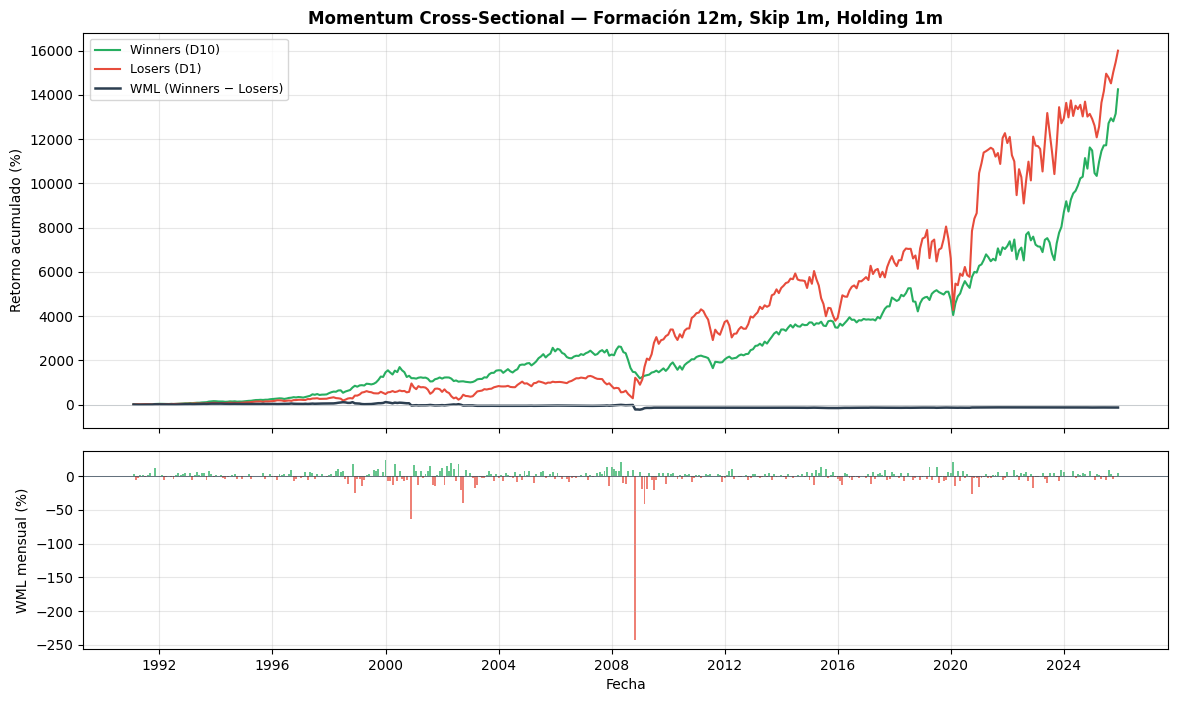

  Guardado: momentum_cumulative.png


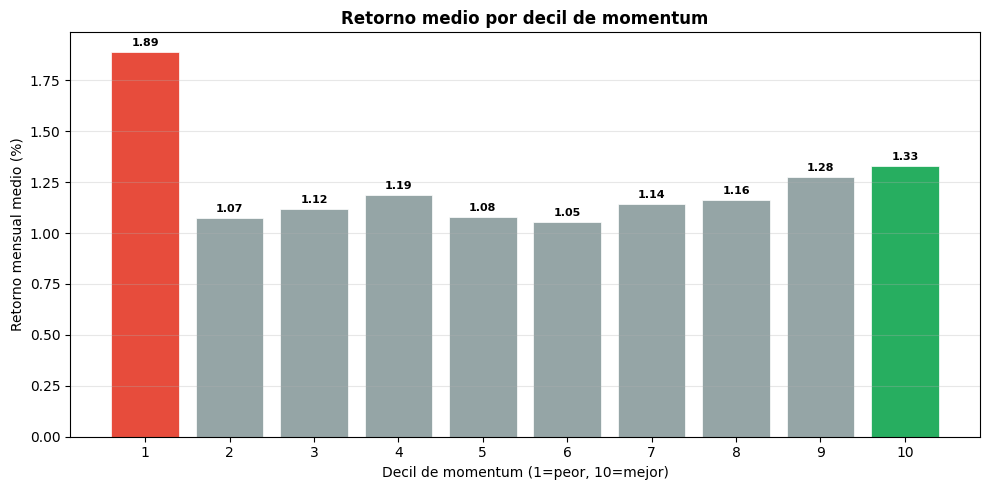

  Guardado: momentum_by_quantile.png


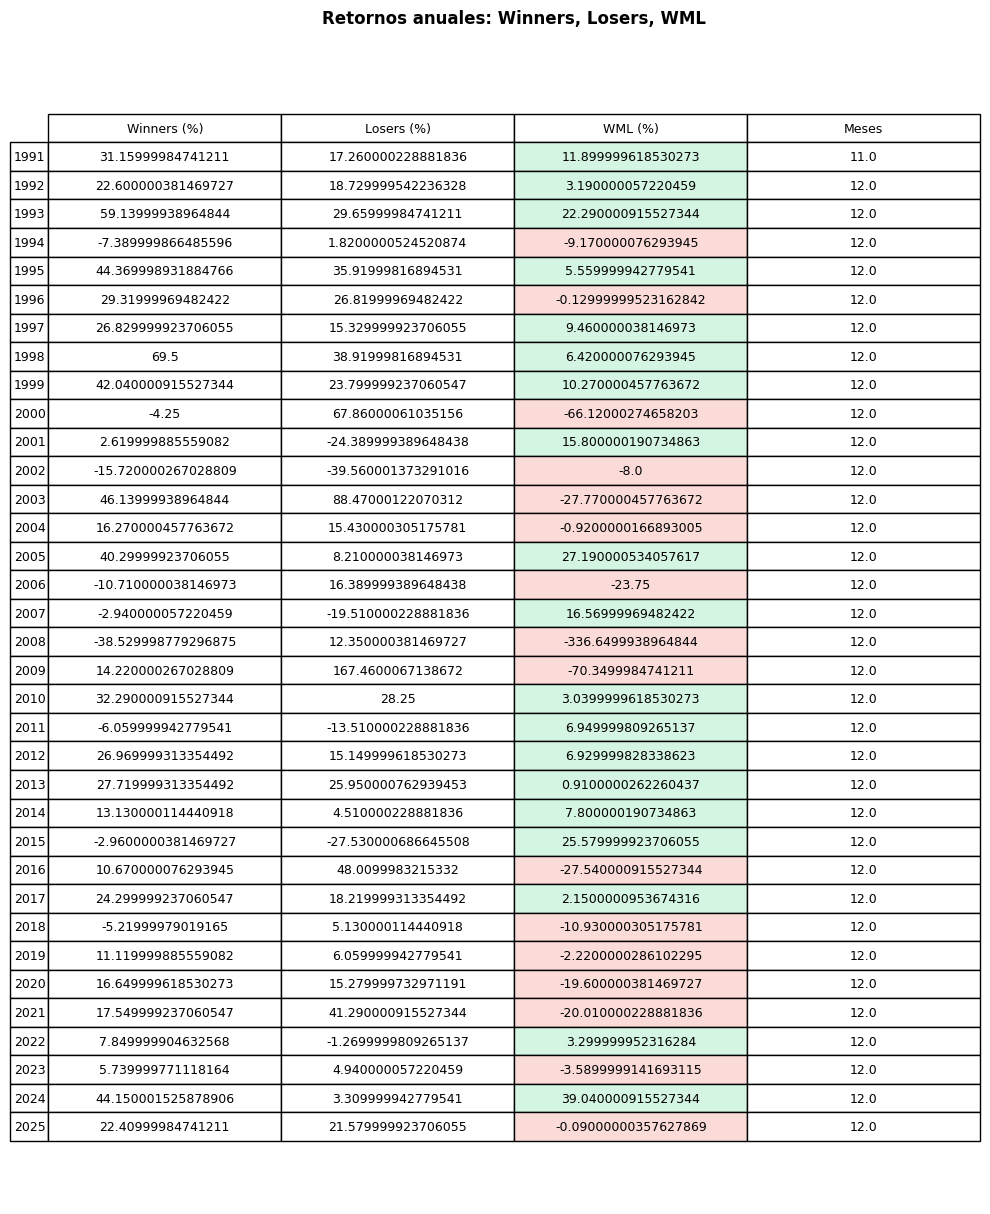

  Guardado: momentum_annual.png

  Guardados: momentum_signals.parquet, momentum_wml.parquet


In [ ]:
"""
run_momentum_strategy.py
========================
Estrategia de Momentum Cross-Sectional sobre el S&P 500.

Lógica (Jegadeesh & Titman, 1993):
    1. FORMACIÓN   → Para cada fecha de rebalanceo, calcular la
                     rentabilidad pasada de cada acción en una ventana
                     (ej: 12 meses), excluyendo el mes más reciente
                     (skip period) para evitar el efecto de reversión
                     a corto plazo.
    2. RANKING     → Ordenar todas las acciones por su retorno de
                     formación y asignar deciles (1 = peor, 10 = mejor).
    3. PORTAFOLIO  → Comprar el decil superior (Winners) y vender/evitar
                     el decil inferior (Losers). Posición equal-weight
                     dentro de cada decil.
    4. HOLDING     → Mantener hasta el siguiente rebalanceo (mensual
                     o trimestral).
    5. EVALUACIÓN  → Medir retorno del portafolio Winners, Losers,
                     y el spread Winners − Losers (WML: Winners Minus Losers).

¿Por qué funciona (hipótesis)?
    - Behavioral: los inversores subreaccionan a noticias → los ganadores
      siguen ganando por inercia.
    - Riesgo: momentum compensa un riesgo de crash (left tail).
    - Información: el precio incorpora información gradualmente.

Dataset esperado:
    date, symbol, close, volume, in_sp500 (mínimo)
    open, high, low (opcional, para métricas adicionales)

Uso:
    python run_momentum_strategy.py

    O importar:
        from run_momentum_strategy import MomentumParams, main
        df, portfolio = main(MomentumParams(formation_months=6))
"""

# ═══════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ═══════════════════════════════════════════════════════════════
# 1) PARÁMETROS
# ═══════════════════════════════════════════════════════════════

@dataclass
class MomentumParams:
    """
    Parámetros centralizados de la estrategia de momentum.

    Atributos
    ---------
    parquet_path : str
        Ruta al fichero parquet con los datos.

    filter_sp500 : bool
        Si True, solo usa acciones que están en el S&P 500.

    formation_months : int
        Meses de ventana para calcular el retorno pasado (señal).
        Clásico: 12. Alternativas: 6, 9.

    skip_months : int
        Meses recientes a excluir del cálculo de formación.
        Clásico: 1. Motivo: el mes más reciente muestra reversión
        a corto plazo (efecto de microestructura), no momentum.

    holding_months : int
        Meses que se mantiene cada portafolio antes de rebalancear.
        1 = mensual, 3 = trimestral.

    rebalance_freq : str
        Frecuencia de rebalanceo: "M" (fin de mes) o "Q" (fin de trimestre).

    n_quantiles : int
        Número de grupos para el ranking. 10 = deciles (clásico).
        5 = quintiles (menos granular pero más acciones por grupo).

    top_quantile : int
        Decil a comprar (Winners). Con n_quantiles=10, top=10 es el mejor.

    bottom_quantile : int
        Decil a vender/evitar (Losers). Con n_quantiles=10, bottom=1.

    min_stocks_per_quantile : int
        Mínimo de acciones para que un decil sea válido.
        Evita portafolios con 1-2 acciones.

    min_history_days : int
        Días mínimos de historia para incluir una acción en el ranking.

    volume_filter_percentile : float
        Excluir acciones con volumen medio por debajo de este percentil.
        0.2 = excluir el 20% menos líquido. 0.0 = sin filtro.
    """
    # --- Datos ---
    parquet_path: str = "sp500_history.parquet"
    filter_sp500: bool = True

    # --- Formación (señal) ---
    formation_months: int = 12
    skip_months: int = 1

    # --- Holding (portafolio) ---
    holding_months: int = 1
    rebalance_freq: str = "M"          # "M" mensual, "Q" trimestral

    # --- Ranking ---
    n_quantiles: int = 10              # 10 = deciles
    top_quantile: int = 10             # Winners
    bottom_quantile: int = 1           # Losers
    min_stocks_per_quantile: int = 5

    # --- Filtros ---
    min_history_days: int = 126        # ~6 meses bursátiles
    volume_filter_percentile: float = 0.20


# ═══════════════════════════════════════════════════════════════
# 2) CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════

def load_data(params: MomentumParams) -> pd.DataFrame:
    """Carga el parquet, filtra y prepara."""
    path = Path(params.parquet_path)
    if not path.exists():
        raise FileNotFoundError(f"No se encontró: {path.resolve()}")

    df = pd.read_parquet(path)
    df["date"] = pd.to_datetime(df["date"])

    if params.filter_sp500 and "in_sp500" in df.columns:
        df = df[df["in_sp500"] == 1].copy()

    # Columnas esenciales
    essential = ["date", "symbol", "close", "volume"]
    missing = [c for c in essential if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas: {missing}")

    df = df.dropna(subset=["close", "volume"])
    df = df[df["volume"] > 0]
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

    print(f"  Registros cargados: {len(df):,}")
    print(f"  Símbolos únicos:    {df['symbol'].nunique()}")
    print(f"  Rango:              {df['date'].min().date()} → {df['date'].max().date()}")

    return df


# ═══════════════════════════════════════════════════════════════
# 3) PRECIOS MENSUALES Y RETORNOS DE FORMACIÓN
# ═══════════════════════════════════════════════════════════════

def compute_monthly_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reduce a frecuencia mensual: precio de cierre del ÚLTIMO día
    de negociación de cada mes por símbolo.

    ¿Por qué mensual?
        - Reduce ruido diario.
        - Alinea todas las acciones en las mismas fechas.
        - Es la frecuencia estándar en la literatura de momentum.
    """
    # Último día de cada mes por símbolo
    df = df.copy()
    df["year_month"] = df["date"].dt.to_period("M")

    # Para cada (symbol, year_month) tomar la última observación
    monthly = (
        df.sort_values("date")
        .groupby(["symbol", "year_month"])
        .agg(
            date=("date", "last"),
            close=("close", "last"),
            volume_avg=("volume", "mean"),     # volumen medio del mes
            n_days=("date", "count"),           # días de cotización
        )
        .reset_index()
    )

    monthly = monthly.sort_values(["symbol", "year_month"]).reset_index(drop=True)

    print(f"  Registros mensuales: {len(monthly):,}")
    return monthly


def compute_formation_return(
    monthly: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Calcula el retorno de formación para cada (símbolo, mes).

    formation_return = close_{t - skip} / close_{t - skip - formation} - 1

    Ejemplo con defaults (formation=12, skip=1):
        Para ranking en enero 2024:
        - Excluimos diciembre 2023 (skip=1)
        - Retorno = close_nov_2023 / close_nov_2022 - 1
        → Rentabilidad de 12 meses terminando 1 mes antes.

    ¿Por qué el skip?
        Jegadeesh & Titman (1993) documentan que el mes más reciente
        muestra reversión (short-term reversal), no momentum.
        Excluirlo mejora la señal.
    """
    g = monthly.groupby("symbol")

    # Precio hace `skip` meses (numerador)
    monthly["close_skip"] = g["close"].shift(params.skip_months)

    # Precio hace `skip + formation` meses (denominador)
    total_lag = params.skip_months + params.formation_months
    monthly["close_formation_start"] = g["close"].shift(total_lag)

    # Retorno de formación
    monthly["formation_return"] = (
        monthly["close_skip"] / monthly["close_formation_start"] - 1
    )

    # Contar meses de historia disponibles
    monthly["months_history"] = g.cumcount()

    return monthly


# ═══════════════════════════════════════════════════════════════
# 4) FILTRO DE LIQUIDEZ
# ═══════════════════════════════════════════════════════════════

def apply_liquidity_filter(
    monthly: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Excluye acciones con volumen medio por debajo de un percentil.

    ¿Por qué?
        - Acciones ilíquidas tienen spreads altos → el coste de
          ejecución puede comerse el alpha.
        - El momentum funciona mejor en acciones líquidas.
        - Evita supervivencia de penny stocks.
    """
    if params.volume_filter_percentile <= 0:
        monthly["passes_liquidity"] = True
        return monthly

    # Percentil de volumen por mes
    monthly["vol_percentile_rank"] = (
        monthly.groupby("year_month")["volume_avg"]
        .rank(pct=True)
    )
    monthly["passes_liquidity"] = (
        monthly["vol_percentile_rank"] >= params.volume_filter_percentile
    )

    excluded = (~monthly["passes_liquidity"]).sum()
    print(f"  Filtro liquidez: excluidas {excluded:,} obs "
          f"(percentil < {params.volume_filter_percentile:.0%})")

    return monthly


# ═══════════════════════════════════════════════════════════════
# 5) RANKING Y ASIGNACIÓN DE DECILES
# ═══════════════════════════════════════════════════════════════

def assign_quantiles(
    monthly: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Para cada mes, rankea las acciones por su formation_return
    y asigna un decil (1 = peor, 10 = mejor).

    Criterios de inclusión:
        - Tiene formation_return calculado (no NaN).
        - Pasa el filtro de liquidez.
        - Tiene suficiente historia.

    El ranking es relativo: compara acciones ENTRE SÍ en el mismo mes.
    Esto es el "cross-sectional" del nombre.
    """
    monthly = monthly.copy()
    monthly["momentum_quantile"] = np.nan

    # Solo filas elegibles
    eligible = (
        monthly["formation_return"].notna()
        & monthly["passes_liquidity"]
        & (monthly["months_history"] >= (params.skip_months + params.formation_months))
    )

    # Asignar cuantiles dentro de cada mes
    monthly.loc[eligible, "momentum_quantile"] = (
        monthly.loc[eligible]
        .groupby("year_month")["formation_return"]
        .transform(
            lambda x: pd.qcut(x, q=params.n_quantiles, labels=False, duplicates="drop") + 1
        )
    )

    # Contar acciones por decil/mes
    q_counts = (
        monthly[monthly["momentum_quantile"].notna()]
        .groupby(["year_month", "momentum_quantile"])
        .size()
        .unstack(fill_value=0)
    )
    print(f"  Acciones por decil (media): "
          f"{q_counts.mean().round(1).to_dict()}")

    return monthly


# ═══════════════════════════════════════════════════════════════
# 6) RETORNOS FORWARD (HOLDING PERIOD)
# ═══════════════════════════════════════════════════════════════

def compute_holding_return(
    monthly: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Retorno del siguiente período de holding.

    holding_return = close_{t + holding_months} / close_t - 1

    Este es el retorno que CAPTURA el portafolio formado en t.
    Se calcula sobre el close del mes actual al close del mes
    t + holding_months.
    """
    g = monthly.groupby("symbol")

    monthly["forward_close"] = g["close"].shift(-params.holding_months)
    monthly["holding_return"] = monthly["forward_close"] / monthly["close"] - 1

    # Retornos adicionales para análisis
    for h in [1, 3, 6]:
        col = f"fwd_ret_{h}m"
        if col not in monthly.columns:
            fwd = g["close"].shift(-h)
            monthly[col] = fwd / monthly["close"] - 1

    return monthly


# ═══════════════════════════════════════════════════════════════
# 7) CONSTRUCCIÓN DE PORTAFOLIOS
# ═══════════════════════════════════════════════════════════════

def build_portfolios(
    monthly: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Construye los portafolios equal-weight por decil para cada mes.

    Genera un DataFrame con una fila por (year_month, quantile):
        - n_stocks:        acciones en el portafolio
        - mean_return:     retorno medio (equal-weight) del período
        - median_return:   retorno mediano
        - formation_mean:  retorno de formación medio (la señal)
        - hit_rate:        % de acciones con retorno positivo

    El portafolio clave es:
        WML = Winners (top) - Losers (bottom)
    """
    valid = monthly[
        monthly["momentum_quantile"].notna()
        & monthly["holding_return"].notna()
    ].copy()

    # Agregación por (mes, decil)
    portfolios = (
        valid.groupby(["year_month", "momentum_quantile"])
        .agg(
            n_stocks=("symbol", "count"),
            mean_return=("holding_return", "mean"),
            median_return=("holding_return", "median"),
            formation_mean=("formation_return", "mean"),
            hit_rate=("holding_return", lambda x: (x > 0).mean()),
            vol_avg=("volume_avg", "mean"),
        )
        .reset_index()
    )

    # Filtrar deciles con pocas acciones
    portfolios = portfolios[
        portfolios["n_stocks"] >= params.min_stocks_per_quantile
    ]

    print(f"  Meses con portafolios válidos: "
          f"{portfolios['year_month'].nunique()}")

    return portfolios


def compute_wml_spread(
    portfolios: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Calcula el spread Winners Minus Losers (WML) para cada mes.

    WML = retorno(Winners) - retorno(Losers)

    Si WML > 0 de media → momentum funciona.
    """
    winners = portfolios[
        portfolios["momentum_quantile"] == params.top_quantile
    ].set_index("year_month")["mean_return"].rename("winners_ret")

    losers = portfolios[
        portfolios["momentum_quantile"] == params.bottom_quantile
    ].set_index("year_month")["mean_return"].rename("losers_ret")

    wml = pd.concat([winners, losers], axis=1).dropna()
    wml["wml_spread"] = wml["winners_ret"] - wml["losers_ret"]
    wml["winners_cum"] = (1 + wml["winners_ret"]).cumprod() - 1
    wml["losers_cum"] = (1 + wml["losers_ret"]).cumprod() - 1
    wml["wml_cum"] = (1 + wml["wml_spread"]).cumprod() - 1

    return wml.reset_index()


# ═══════════════════════════════════════════════════════════════
# 8) REPORTES
# ═══════════════════════════════════════════════════════════════

def report_momentum_by_quantile(
    portfolios: pd.DataFrame,
    params: MomentumParams
) -> pd.DataFrame:
    """
    Tabla central: retorno medio por decil.
    Si momentum funciona, debe haber una relación monótona
    creciente del decil 1 al 10.
    """
    summary = (
        portfolios.groupby("momentum_quantile")
        .agg(
            n_months=("year_month", "nunique"),
            avg_stocks=("n_stocks", "mean"),
            ret_mean=("mean_return", "mean"),
            ret_median=("mean_return", "median"),
            ret_std=("mean_return", "std"),
            hit_rate=("hit_rate", "mean"),
            formation_mean=("formation_mean", "mean"),
        )
    )

    summary["ret_mean_ann"] = ((1 + summary["ret_mean"]) ** 12 - 1)
    summary["sharpe_approx"] = (
        summary["ret_mean"] / summary["ret_std"] * np.sqrt(12)
    )

    # Formatear
    for col in ["ret_mean", "ret_median", "ret_std", "ret_mean_ann", "formation_mean"]:
        summary[col] = (summary[col] * 100).round(3)
    summary["hit_rate"] = (summary["hit_rate"] * 100).round(1)
    summary["sharpe_approx"] = summary["sharpe_approx"].round(3)
    summary["avg_stocks"] = summary["avg_stocks"].round(1)

    summary.columns = [
        "Meses", "Stocks/mes", "Ret mensual (%)", "Ret mediano (%)",
        "Std mensual (%)", "Hit Rate (%)", "Form. Return (%)",
        "Ret anualiz. (%)", "Sharpe (aprox)"
    ]
    return summary


def report_wml_statistics(wml: pd.DataFrame) -> dict:
    """Estadísticos del spread WML."""
    s = wml["wml_spread"]
    stats = {
        "WML medio mensual": f"{s.mean() * 100:.3f}%",
        "WML mediano mensual": f"{s.median() * 100:.3f}%",
        "WML std mensual": f"{s.std() * 100:.3f}%",
        "WML anualizado": f"{((1 + s.mean()) ** 12 - 1) * 100:.2f}%",
        "Sharpe WML (aprox)": f"{s.mean() / s.std() * np.sqrt(12):.3f}",
        "% meses WML > 0": f"{(s > 0).mean() * 100:.1f}%",
        "Peor mes WML": f"{s.min() * 100:.2f}%",
        "Mejor mes WML": f"{s.max() * 100:.2f}%",
        "Meses totales": len(s),
        "Acumulado Winners": f"{wml['winners_cum'].iloc[-1] * 100:.1f}%",
        "Acumulado Losers": f"{wml['losers_cum'].iloc[-1] * 100:.1f}%",
        "Acumulado WML": f"{wml['wml_cum'].iloc[-1] * 100:.1f}%",
    }
    return stats


def report_annual_returns(wml: pd.DataFrame) -> pd.DataFrame:
    """Retorno anual de Winners, Losers y WML."""
    wml = wml.copy()
    wml["year"] = wml["year_month"].dt.year

    annual = wml.groupby("year").agg(
        winners=("winners_ret", lambda x: (1 + x).prod() - 1),
        losers=("losers_ret", lambda x: (1 + x).prod() - 1),
        wml=("wml_spread", lambda x: (1 + x).prod() - 1),
        n_months=("wml_spread", "count"),
    )

    for col in ["winners", "losers", "wml"]:
        annual[col] = (annual[col] * 100).round(2)

    annual.columns = ["Winners (%)", "Losers (%)", "WML (%)", "Meses"]
    return annual


# ═══════════════════════════════════════════════════════════════
# 9) VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════

def plot_cumulative_returns(wml: pd.DataFrame, params: MomentumParams):
    """
    Gráfico principal: rentabilidad acumulada de Winners, Losers
    y el spread WML.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1],
                              sharex=True, gridspec_kw={"hspace": 0.08})

    dates = wml["year_month"].dt.to_timestamp()

    # --- Panel 1: Acumulados ---
    ax1 = axes[0]
    ax1.plot(dates, wml["winners_cum"] * 100, color="#27ae60",
             linewidth=1.5, label=f"Winners (D{params.top_quantile})")
    ax1.plot(dates, wml["losers_cum"] * 100, color="#e74c3c",
             linewidth=1.5, label=f"Losers (D{params.bottom_quantile})")
    ax1.plot(dates, wml["wml_cum"] * 100, color="#2c3e50",
             linewidth=1.8, label="WML (Winners − Losers)")
    ax1.axhline(0, color="#bdc3c7", linewidth=0.5)
    ax1.set_ylabel("Retorno acumulado (%)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.set_title(
        f"Momentum Cross-Sectional — Formación {params.formation_months}m, "
        f"Skip {params.skip_months}m, Holding {params.holding_months}m",
        fontsize=12, fontweight="bold"
    )
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: WML mensual ---
    ax2 = axes[1]
    colors = ["#27ae60" if v > 0 else "#e74c3c" for v in wml["wml_spread"]]
    ax2.bar(dates, wml["wml_spread"] * 100, color=colors, width=25, alpha=0.7)
    ax2.axhline(0, color="#2c3e50", linewidth=0.5)
    ax2.set_ylabel("WML mensual (%)")
    ax2.set_xlabel("Fecha")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("momentum_cumulative.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: momentum_cumulative.png")


def plot_quantile_returns(summary: pd.DataFrame, params: MomentumParams):
    """
    Gráfico de barras: retorno medio mensual por decil.
    Si momentum funciona → barras crecientes de izquierda a derecha.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    quantiles = summary.index
    returns = summary["Ret mensual (%)"]
    colors = ["#e74c3c" if q <= params.bottom_quantile
              else "#27ae60" if q >= params.top_quantile
              else "#95a5a6" for q in quantiles]

    bars = ax.bar(quantiles, returns, color=colors, edgecolor="white", linewidth=0.5)

    ax.set_xlabel(f"Decil de momentum (1=peor, {params.n_quantiles}=mejor)")
    ax.set_ylabel("Retorno mensual medio (%)")
    ax.set_title("Retorno medio por decil de momentum", fontsize=12, fontweight="bold")
    ax.set_xticks(quantiles)
    ax.axhline(0, color="#2c3e50", linewidth=0.5)
    ax.grid(True, alpha=0.3, axis="y")

    # Anotar valores
    for bar, val in zip(bars, returns):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.savefig("momentum_by_quantile.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: momentum_by_quantile.png")


def plot_annual_heatmap(annual: pd.DataFrame):
    """Tabla visual de retornos anuales."""
    fig, ax = plt.subplots(figsize=(10, max(4, len(annual) * 0.35)))

    ax.axis("off")
    table = ax.table(
        cellText=annual.values,
        rowLabels=annual.index,
        colLabels=annual.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.4)

    # Colorear WML
    wml_col_idx = list(annual.columns).index("WML (%)")
    for i, (_, row) in enumerate(annual.iterrows()):
        val = row["WML (%)"]
        color = "#d5f5e3" if val > 0 else "#fadbd8"
        table[i + 1, wml_col_idx].set_facecolor(color)

    ax.set_title("Retornos anuales: Winners, Losers, WML",
                 fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig("momentum_annual.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: momentum_annual.png")


# ═══════════════════════════════════════════════════════════════
# 10) PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════

def main(
    params: Optional[MomentumParams] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta la estrategia completa de momentum cross-sectional.

    Returns
    -------
    monthly : DataFrame con todos los datos mensuales y señales.
    wml     : DataFrame con retornos de Winners, Losers y spread.
    """
    if params is None:
        params = MomentumParams()

    # --- Config ---
    print("=" * 65)
    print("  ESTRATEGIA MOMENTUM CROSS-SECTIONAL")
    print("=" * 65)
    print(f"  Formación:        {params.formation_months} meses")
    print(f"  Skip:             {params.skip_months} mes(es)")
    print(f"  Holding:          {params.holding_months} mes(es)")
    print(f"  Quantiles:        {params.n_quantiles} (deciles)")
    print(f"  Winners:          D{params.top_quantile} | Losers: D{params.bottom_quantile}")
    print(f"  Filtro liquidez:  percentil ≥ {params.volume_filter_percentile:.0%}")
    print(f"  Filtro S&P 500:   {params.filter_sp500}")
    print("=" * 65)

    # [1] Cargar
    print("\n[1/6] Cargando datos...")
    df = load_data(params)

    # [2] Precios mensuales
    print("\n[2/6] Agregando a frecuencia mensual...")
    monthly = compute_monthly_prices(df)

    # [3] Retorno de formación
    print("\n[3/6] Calculando retornos de formación...")
    monthly = compute_formation_return(monthly, params)

    # [4] Filtro de liquidez
    print("\n[4/6] Aplicando filtro de liquidez...")
    monthly = apply_liquidity_filter(monthly, params)

    # [5] Ranking
    print("\n[5/6] Asignando deciles de momentum...")
    monthly = assign_quantiles(monthly, params)

    # [6] Retornos forward
    print("\n[6/6] Calculando retornos del período de holding...")
    monthly = compute_holding_return(monthly, params)

    # ═══════════════════════════════════════════════════════════
    # PORTAFOLIOS Y REPORTES
    # ═══════════════════════════════════════════════════════════

    print("\n" + "=" * 65)
    print("  CONSTRUYENDO PORTAFOLIOS")
    print("=" * 65)
    portfolios = build_portfolios(monthly, params)
    wml = compute_wml_spread(portfolios, params)

    # --- Reporte por decil ---
    print("\n" + "=" * 65)
    print("  RETORNO MEDIO POR DECIL DE MOMENTUM")
    print("=" * 65)
    q_summary = report_momentum_by_quantile(portfolios, params)
    print(q_summary.to_string())

    # --- WML ---
    print("\n" + "=" * 65)
    print("  ESTADÍSTICOS WML (WINNERS MINUS LOSERS)")
    print("=" * 65)
    wml_stats = report_wml_statistics(wml)
    for k, v in wml_stats.items():
        print(f"  {k:<30s} {v}")

    # --- Anuales ---
    print("\n" + "=" * 65)
    print("  RETORNOS ANUALES")
    print("=" * 65)
    annual = report_annual_returns(wml)
    print(annual.to_string())

    # ═══════════════════════════════════════════════════════════
    # GRÁFICOS
    # ═══════════════════════════════════════════════════════════

    print("\n  Generando gráficos...")
    plot_cumulative_returns(wml, params)
    plot_quantile_returns(q_summary, params)
    plot_annual_heatmap(annual)

    # ═══════════════════════════════════════════════════════════
    # GUARDAR
    # ═══════════════════════════════════════════════════════════

    monthly.to_parquet("momentum_signals.parquet", index=False)
    wml.to_parquet("momentum_wml.parquet", index=False)
    print(f"\n  Guardados: momentum_signals.parquet, momentum_wml.parquet")

    return monthly, wml


# ═══════════════════════════════════════════════════════════════
# EJECUCIÓN
# ═══════════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ──────────────────────────────────────────────────────────
    # AJUSTAR PARÁMETROS AQUÍ
    # ──────────────────────────────────────────────────────────
    params = MomentumParams(
        parquet_path="sp500_history.parquet",
        filter_sp500=True,

        formation_months=12,        # Ventana de señal: 12 meses
        skip_months=1,              # Excluir mes más reciente
        holding_months=1,           # Rebalanceo mensual

        n_quantiles=10,             # Deciles
        top_quantile=10,            # Comprar top decil
        bottom_quantile=1,          # Vender/evitar bottom decil

        volume_filter_percentile=0.20,  # Excluir 20% menos líquido
    )

    monthly, wml = main(params)